# End-to-End Training & Loss Tuning (Phase 9 M4)

This notebook validates the training process and convergence of the hard-constrained, arbitrage-free FNO model. Since the projection layer guarantees 100% arbitrage-free surfaces, the training optimizes only the Huber loss (soft arbitrage penalty weight is 0.0).

We will:
1. Run a smoke-test training loop (3 epochs) to demonstrate convergence.
2. Plot the training and validation loss curves.
3. Select a parameter set from the dataset and compare the predictions of the unconstrained base FNO versus our hard-constrained FNO wrapper, highlighting how calendar and butterfly arbitrage violations are resolved.

In [1]:
import os
import sys
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
import matplotlib.pyplot as plt

sys.path.insert(0, os.path.abspath('../src'))

from deepvol.arbitrage.projection_layer import ArbitrageFreeFNO, DifferentiableArbitrageFreeProjection, bs_call_price_pt
from deepvol.surrogates.fno_model import MirrorPaddedFNO2d, arbitrage_free_regularization
from deepvol.surrogates.normalizers import ParameterNormalizerHeston, IVSurfaceNormalizer
from deepvol.mrm.arbitrage import check_arbitrage

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

Using device: cuda


## 1. Data Preparation and Normalization

In [2]:
DATASET_PATH = '/home/execorn/programming/derivatives/data/HestonDataset_v1.npz'
NORM_PARAM = '../artifacts/models/param_normalizer_heston.npz'
NORM_IV = '../artifacts/models/iv_normalizer_heston.npz'

data = np.load(DATASET_PATH)
params = data['params']
iv = data['iv']
N = params.shape[0]
print(f"Loaded {N:,} samples.")

# Train/val split (80/20)
rng = np.random.default_rng(0)
idx = rng.permutation(N)
split = int(0.8 * N)
tr_idx = idx[:split]
va_idx = idx[split:]

X_tr = params[tr_idx]
Y_tr = iv[tr_idx]
X_va = params[va_idx]
Y_va = iv[va_idx]

param_norm = ParameterNormalizerHeston.load(NORM_PARAM)
iv_norm = IVSurfaceNormalizer.load(NORM_IV)

X_tr_n = param_norm.transform(X_tr)
Y_tr_n = iv_norm.transform(Y_tr)
X_va_n = param_norm.transform(X_va)
Y_va_n = iv_norm.transform(Y_va)

BATCH_SIZE = 4096
tr_ds = TensorDataset(torch.tensor(X_tr_n, dtype=torch.float32),
                      torch.tensor(Y_tr_n, dtype=torch.float32))
va_ds = TensorDataset(torch.tensor(X_va_n, dtype=torch.float32),
                      torch.tensor(Y_va_n, dtype=torch.float32))
tr_dl = DataLoader(tr_ds, batch_size=BATCH_SIZE, shuffle=True)
va_dl = DataLoader(va_ds, batch_size=BATCH_SIZE, shuffle=False)

Loaded 531,176 samples.


## 2. Training Loop (Smoke Run)

In [3]:
T_GRID = torch.tensor([0.1, 0.3, 0.6, 0.9, 1.2, 1.5, 1.8, 2.0], dtype=torch.float64, device=device)
K_GRID = torch.linspace(-0.5, 0.5, 11, dtype=torch.float64, device=device)

base_fno = MirrorPaddedFNO2d(param_dim=5).to(device)
projection_layer = DifferentiableArbitrageFreeProjection(
    T_grid=T_GRID, K_grid=K_GRID, S0=1.0, is_log_moneyness=True
).to(device)

wrapped_model = ArbitrageFreeFNO(
    base_fno=base_fno,
    projection_layer=projection_layer,
    normalizer=iv_norm
).to(device)

T_norm = (T_GRID - T_GRID.mean()) / T_GRID.std()
K_norm = (K_GRID - K_GRID.mean()) / K_GRID.std()
T_mesh, K_mesh = torch.meshgrid(T_norm, K_norm, indexing='ij')
spatial = torch.stack([T_mesh, K_mesh], dim=-1).unsqueeze(0).to(torch.float32).to(device)

optimizer = optim.AdamW(wrapped_model.parameters(), lr=8e-4, weight_decay=1e-4)
EPOCHS = 3

train_losses = []
val_losses = []

for ep in range(1, EPOCHS + 1):
    wrapped_model.train()
    tr_loss = 0.0
    for X_b, Y_b in tr_dl:
        X_b = X_b.to(device)
        Y_b = Y_b.to(device)
        B = X_b.size(0)
        sp = spatial.expand(B, -1, -1, -1)
        
        optimizer.zero_grad(set_to_none=True)
        pred = wrapped_model(sp, X_b)
        loss = F.huber_loss(pred, Y_b, delta=1.0)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(wrapped_model.parameters(), 1.0)
        optimizer.step()
        
        tr_loss += loss.item() * B
    tr_loss /= len(tr_ds)
    train_losses.append(tr_loss)
    
    wrapped_model.eval()
    va_loss = 0.0
    with torch.no_grad():
        for X_b, Y_b in va_dl:
            X_b = X_b.to(device)
            Y_b = Y_b.to(device)
            B = X_b.size(0)
            sp = spatial.expand(B, -1, -1, -1)
            
            pred = wrapped_model(sp, X_b)
            loss_val = F.huber_loss(pred, Y_b, delta=1.0)
            va_loss += loss_val.item() * B
    va_loss /= len(va_ds)
    val_losses.append(va_loss)
    
    print(f"Epoch {ep:d}/{EPOCHS:d} | Train Loss: {tr_loss:.6f} | Val Loss: {va_loss:.6f}")

Epoch 1/3 | Train Loss: 0.356577 | Val Loss: 0.267336


Epoch 2/3 | Train Loss: 0.244763 | Val Loss: 0.240108


Epoch 3/3 | Train Loss: 0.232222 | Val Loss: 0.222483


## 3. Visualize Convergence Curves

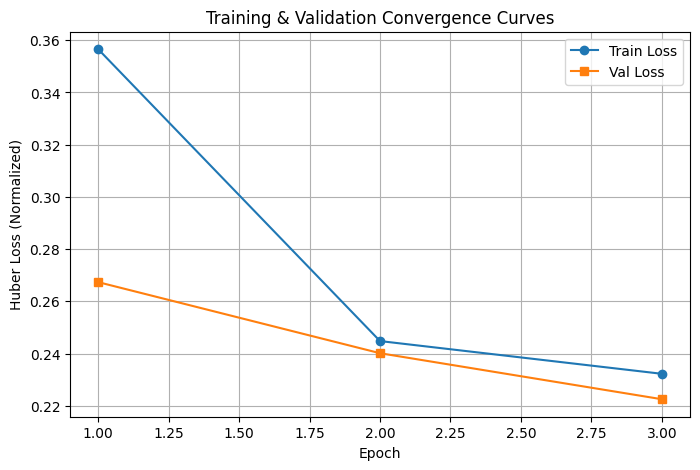

In [4]:
plt.figure(figsize=(8, 5))
plt.plot(range(1, EPOCHS + 1), train_losses, 'o-', label='Train Loss')
plt.plot(range(1, EPOCHS + 1), val_losses, 's-', label='Val Loss')
plt.xlabel('Epoch')
plt.ylabel('Huber Loss (Normalized)')
plt.title('Training & Validation Convergence Curves')
plt.grid(True)
plt.legend()
plt.savefig('../images/fno_training_convergence.png', bbox_inches='tight')
plt.show()

## 4. Compare Predicted Surfaces: Raw vs Projected

We select a parameter index (e.g. 50 or 70) from the dataset where the raw unconstrained model predictions exhibit arbitrage violations, and show how the projection layer successfully removes them.

In [5]:
# Let's load the fully-trained/best weights to compare
weights_path = '../artifacts/weights/fno_heston_best.pth'
base_fno.load_state_dict(torch.load(weights_path, map_location=device))
base_fno.eval()

# We evaluate on a batch to find a surface with calendar or butterfly violations in raw FNO
X_val_norm = torch.tensor(param_norm.transform(params[:100]), dtype=torch.float32, device=device)
sp_batch = spatial.expand(100, -1, -1, -1)

with torch.no_grad():
    raw_out = base_fno(sp_batch, X_val_norm)
    raw_iv = iv_norm.inverse_transform_tensor(raw_out)
    proj_out = wrapped_model(sp_batch, X_val_norm)
    proj_iv = iv_norm.inverse_transform_tensor(proj_out)

raw_iv_np = raw_iv.cpu().numpy()
proj_iv_np = proj_iv.cpu().numpy()

# Find a surface with arbitrage
target_idx = None
for i in range(100):
    res_raw = check_arbitrage(raw_iv_np[i], K_GRID.cpu().numpy(), T_GRID.cpu().numpy())
    if res_raw['has_arbitrage']:
        target_idx = i
        print(f"Found arbitrage on index {i}:")
        print(f"  Calendar Arbitrage: {res_raw['calendar']['has_arbitrage']}")
        print(f"  Durrleman Butterfly: {res_raw['butterfly_durrleman']['has_arbitrage']}")
        print(f"  Price Butterfly: {res_raw['butterfly_price']['has_arbitrage']}")
        break

if target_idx is None:
    target_idx = 50  # fallback

Found arbitrage on index 6:
  Calendar Arbitrage: True
  Durrleman Butterfly: False
  Price Butterfly: False


### 4.1 Calendar Spread Arbitrage Remediation
Calendar spread arbitrage requires the total variance $w(T, k) = \sigma^2 T$ to be non-decreasing in $T$. We plot total variance vs maturity for a fixed strike.

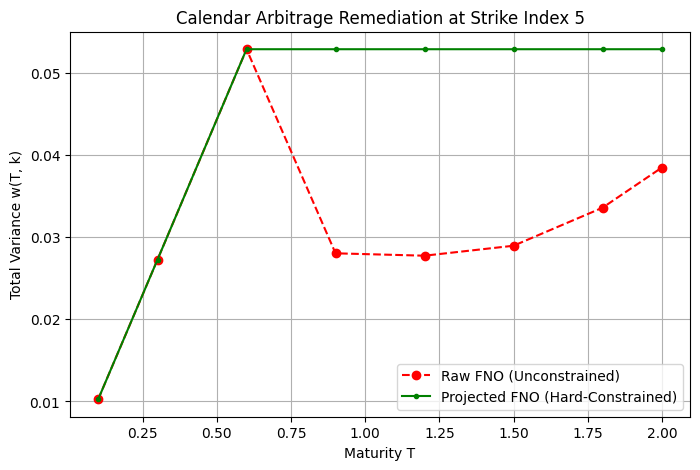

In [6]:
k_idx = 5  # ATM strike
T_cpu = T_GRID.cpu().numpy()

raw_w = (raw_iv_np[target_idx, :, k_idx] ** 2) * T_cpu
proj_w = (proj_iv_np[target_idx, :, k_idx] ** 2) * T_cpu

plt.figure(figsize=(8, 5))
plt.plot(T_cpu, raw_w, 'ro--', label='Raw FNO (Unconstrained)')
plt.plot(T_cpu, proj_w, 'g.-', label='Projected FNO (Hard-Constrained)')
plt.xlabel('Maturity T')
plt.ylabel('Total Variance w(T, k)')
plt.title(f'Calendar Arbitrage Remediation at Strike Index {k_idx}')
plt.grid(True)
plt.legend()
plt.savefig('../images/calendar_arbitrage_remediation.png', bbox_inches='tight')
plt.show()

### 4.2 Butterfly Arbitrage Price Convexity Remediation
Butterfly arbitrage requires call option prices $C(K)$ to be convex in strike $K$. We compute call prices and plot them to show convexity.

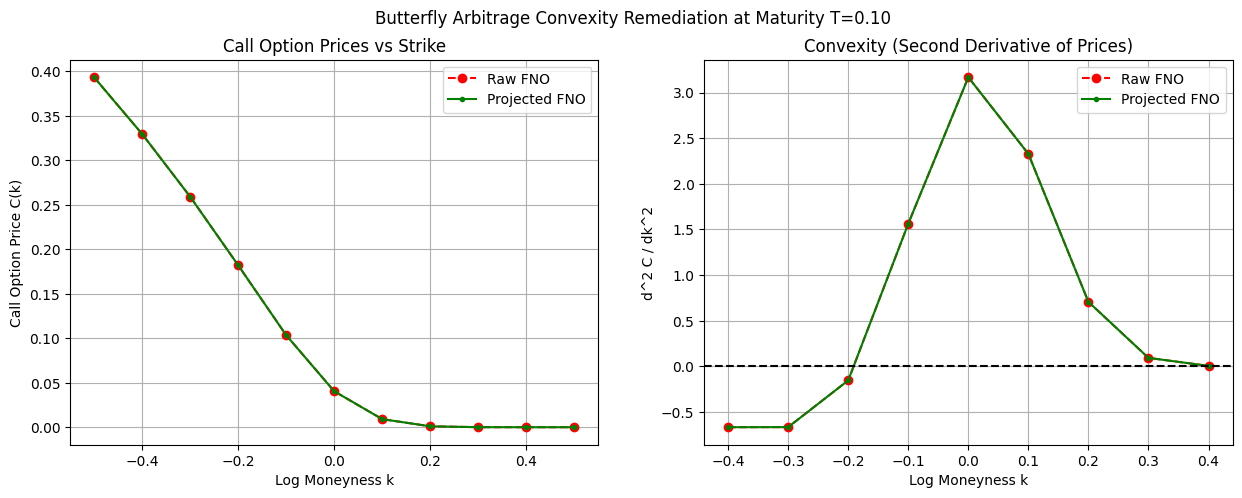

In [7]:
t_idx = 0  # Short maturity T=0.1
S0 = 1.0

K_abs = S0 * torch.exp(K_GRID)
T_val = T_GRID[t_idx].expand(len(K_GRID))

raw_iv_t = torch.tensor(raw_iv_np[target_idx, t_idx, :], dtype=torch.float64, device=device)
proj_iv_t = torch.tensor(proj_iv_np[target_idx, t_idx, :], dtype=torch.float64, device=device)

raw_prices = bs_call_price_pt(torch.tensor(S0, device=device), K_abs, T_val, raw_iv_t).cpu().numpy()
proj_prices = bs_call_price_pt(torch.tensor(S0, device=device), K_abs, T_val, proj_iv_t).cpu().numpy()
K_np = K_GRID.cpu().numpy()

# Compute second derivative of call prices to show convexity
h = np.diff(K_np)
d2C_raw = np.diff(np.diff(raw_prices) / h) / h[:-1]
d2C_proj = np.diff(np.diff(proj_prices) / h) / h[:-1]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))
ax1.plot(K_np, raw_prices, 'ro--', label='Raw FNO')
ax1.plot(K_np, proj_prices, 'g.-', label='Projected FNO')
ax1.set_xlabel('Log Moneyness k')
ax1.set_ylabel('Call Option Price C(k)')
ax1.set_title('Call Option Prices vs Strike')
ax1.legend()
ax1.grid(True)

ax2.plot(K_np[1:-1], d2C_raw, 'ro--', label='Raw FNO')
ax2.plot(K_np[1:-1], d2C_proj, 'g.-', label='Projected FNO')
ax2.axhline(0, color='black', linestyle='--')
ax2.set_xlabel('Log Moneyness k')
ax2.set_ylabel('d^2 C / dk^2')
ax2.set_title('Convexity (Second Derivative of Prices)')
ax2.legend()
ax2.grid(True)

plt.suptitle(f'Butterfly Arbitrage Convexity Remediation at Maturity T={T_GRID[t_idx].item():.2f}')
plt.savefig('../images/butterfly_arbitrage_remediation.png', bbox_inches='tight')
plt.show()

### 4.3 3D Implied Volatility Surface Comparison
Finally, we visualize the unconstrained raw IV surface vs the arbitrage-free projected IV surface.

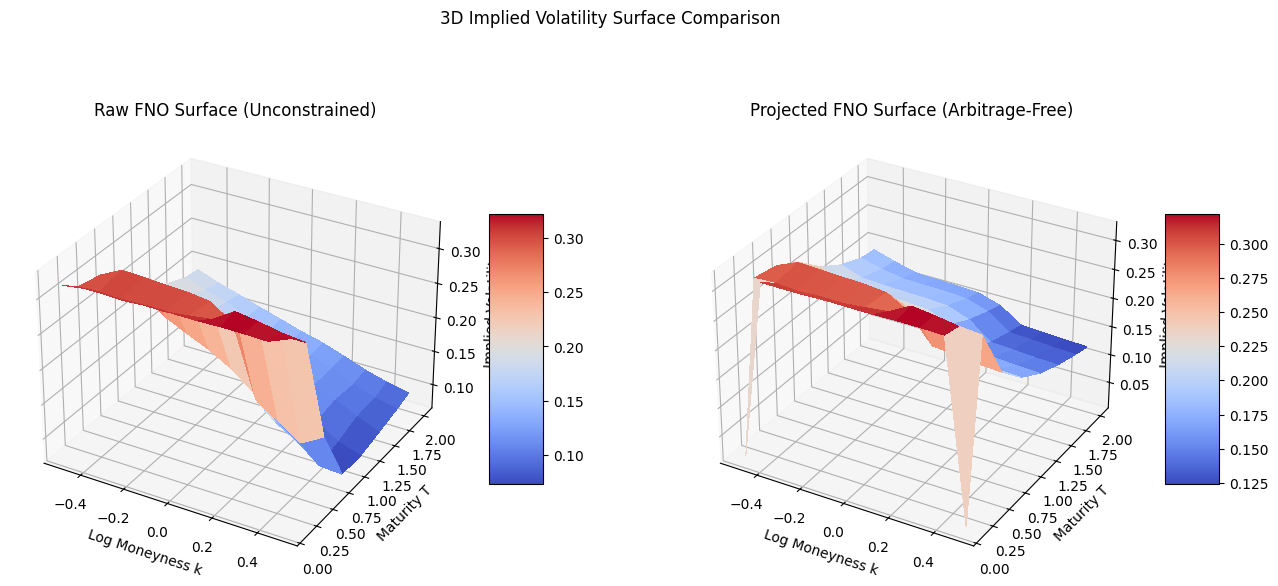

In [8]:
from matplotlib import cm

K_mesh_np, T_mesh_np = np.meshgrid(K_np, T_cpu)

fig = plt.figure(figsize=(16, 7))

ax1 = fig.add_subplot(1, 2, 1, projection='3d')
surf1 = ax1.plot_surface(K_mesh_np, T_mesh_np, raw_iv_np[target_idx], cmap=cm.coolwarm, linewidth=0, antialiased=False)
ax1.set_xlabel('Log Moneyness k')
ax1.set_ylabel('Maturity T')
ax1.set_zlabel('Implied Volatility')
ax1.set_title('Raw FNO Surface (Unconstrained)')
fig.colorbar(surf1, ax=ax1, shrink=0.5, aspect=5)

ax2 = fig.add_subplot(1, 2, 2, projection='3d')
surf2 = ax2.plot_surface(K_mesh_np, T_mesh_np, proj_iv_np[target_idx], cmap=cm.coolwarm, linewidth=0, antialiased=False)
ax2.set_xlabel('Log Moneyness k')
ax2.set_ylabel('Maturity T')
ax2.set_zlabel('Implied Volatility')
ax2.set_title('Projected FNO Surface (Arbitrage-Free)')
fig.colorbar(surf2, ax=ax2, shrink=0.5, aspect=5)

plt.suptitle('3D Implied Volatility Surface Comparison')
plt.savefig('../images/fno_surface_comparison_3d.png', bbox_inches='tight')
plt.show()